导出

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

Time step dt = 0.001
Total time steps Nt = 1000


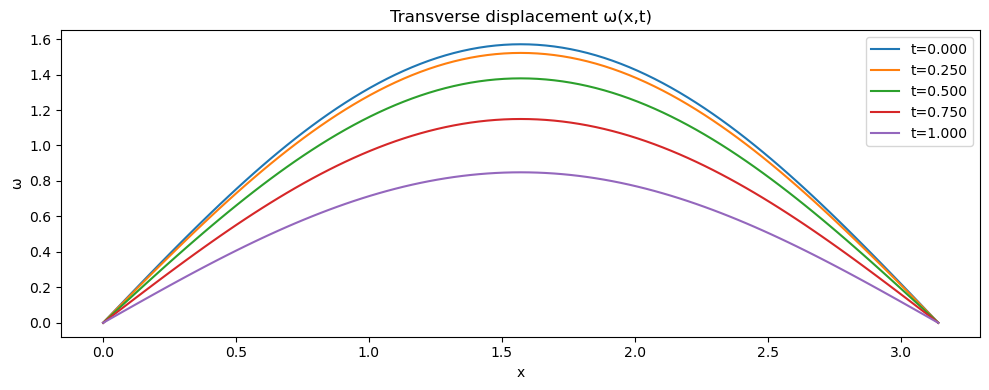

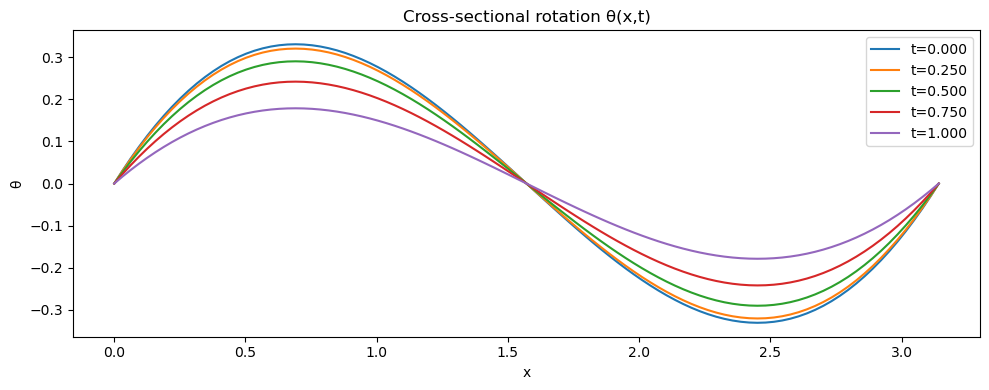

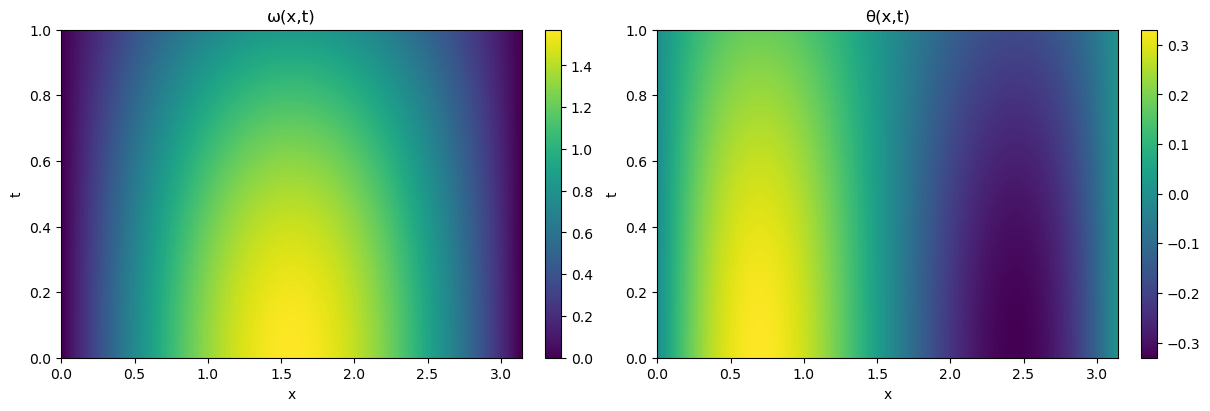

✅ Readable CSV files exported to: results_gpt5_csv


In [4]:
def g_force(x, t):
    return np.cos(t) - (np.pi/2.0) * np.sin(x) * np.cos(t)


def timoshenko_fd(Nx=401, t_max=1.0):
    x0, x1 = 0.0, np.pi
    x = np.linspace(x0, x1, Nx)
    dx = x[1] - x[0]

    # =========================
    # ✅ 固定时间步长 dt = 0.001
    # =========================
    dt = 0.001
    Nt = int(t_max / dt)   # Nt = 1000 when t_max=1.0
    t = np.linspace(0.0, t_max, Nt + 1)

    print(f"Time step dt = {dt}")
    print(f"Total time steps Nt = {Nt}")

    w = np.zeros((Nt + 1, Nx), dtype=np.float64)
    th = np.zeros((Nt + 1, Nx), dtype=np.float64)

    w0 = (np.pi/2.0) * np.sin(x)
    w_t0 = np.zeros_like(x)

    th0 = (np.pi/2.0) * np.cos(x) + (x - np.pi/2.0)
    th_t0 = np.zeros_like(x)

    w0[0] = w0[-1] = 0.0
    th0[0] = th0[-1] = 0.0

    w[0, :] = w0
    th[0, :] = th0

    def D1(u):
        return (u[2:] - u[:-2]) / (2.0 * dx)

    def D2(u):
        return (u[2:] - 2.0 * u[1:-1] + u[:-2]) / (dx * dx)
    
    def rhs_theta(theta, omega, tn):
        theta_xx = D2(theta)
        omega_x = D1(omega)
        diff = theta[1:-1] - omega_x  # θ - ω_x (在内部点)
        return theta_xx - diff

    def rhs_omega(theta, omega, tn, x_interior):
        gval = g_force(x_interior, tn)
        theta_x = D1(theta)  # θ_x
        omega_xx = D2(omega)  # ω_xx
        diff_x = theta_x - omega_xx  # (θ - ω_x)_x = θ_x - ω_xx
        return gval - diff_x
    
    

    tn = t[0]
    x_in = x[1:-1]

    th_tt0 = rhs_theta(th[0, :], w[0, :], tn)
    w_tt0 = rhs_omega(th[0, :], w[0, :], tn, x_in)

    th[1, 1:-1] = th[0, 1:-1] + 0.5 * dt * dt * th_tt0
    w[1, 1:-1]  = w[0, 1:-1]  + 0.5 * dt * dt * w_tt0

    th[1, 0] = th[1, -1] = 0.0
    w[1, 0]  = w[1, -1]  = 0.0

    for n in range(1, Nt):
        tn = t[n]
        th_tt = rhs_theta(th[n, :], w[n, :], tn)
        w_tt  = rhs_omega(th[n, :], w[n, :], tn, x_in)

        th[n + 1, 1:-1] = 2.0 * th[n, 1:-1] - th[n - 1, 1:-1] + (dt * dt) * th_tt
        w[n + 1, 1:-1]  = 2.0 * w[n, 1:-1]  - w[n - 1, 1:-1]  + (dt * dt) * w_tt

        th[n + 1, 0] = th[n + 1, -1] = 0.0
        w[n + 1, 0]  = w[n + 1, -1]  = 0.0

    return x, t, w, th


# =========================================================
# ✅ 统一“可读型 CSV”导出
# =========================================================
def export_results_csv_readable(x, t, w, th, folder_name="results_csv"):
    os.makedirs(folder_name, exist_ok=True)

    w_T = w.T
    th_T = th.T

    df_w = pd.DataFrame(
        w_T,
        index=np.round(x, 6),
        columns=np.round(t, 6)
    )
    df_w.index.name = "x"
    df_w.columns.name = "t"
    df_w.to_csv(os.path.join(folder_name, "omega_full.csv"))

    df_th = pd.DataFrame(
        th_T,
        index=np.round(x, 6),
        columns=np.round(t, 6)
    )
    df_th.index.name = "x"
    df_th.columns.name = "t"
    df_th.to_csv(os.path.join(folder_name, "theta_full.csv"))

    pd.DataFrame({
        "x": x,
        "omega_final": w[-1, :]
    }).to_csv(os.path.join(folder_name, "omega_final.csv"), index=False)

    pd.DataFrame({
        "x": x,
        "theta_final": th[-1, :]
    }).to_csv(os.path.join(folder_name, "theta_final.csv"), index=False)

    print("✅ Readable CSV files exported to:", folder_name)


# =============================
# Main
# =============================
if __name__ == "__main__":
    Nx = 101

    x, t, w, th = timoshenko_fd(Nx=Nx, t_max=1.0)

    snapshot_times = [0.0, 0.25, 0.5, 0.75, 1.0]
    idx = [np.argmin(np.abs(t - ts)) for ts in snapshot_times]

    plt.figure(figsize=(10, 4))
    for n in idx:
        plt.plot(x, w[n, :], label=f"t={t[n]:.3f}")
    plt.title("Transverse displacement ω(x,t)")
    plt.xlabel("x")
    plt.ylabel("ω")
    plt.legend()
    plt.tight_layout()

    plt.figure(figsize=(10, 4))
    for n in idx:
        plt.plot(x, th[n, :], label=f"t={t[n]:.3f}")
    plt.title("Cross-sectional rotation θ(x,t)")
    plt.xlabel("x")
    plt.ylabel("θ")
    plt.legend()
    plt.tight_layout()

    fig, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    im0 = axs[0].imshow(w, aspect='auto', origin='lower',
                        extent=[x[0], x[-1], t[0], t[-1]], cmap='viridis')
    axs[0].set_title("ω(x,t)")
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("t")
    fig.colorbar(im0, ax=axs[0])

    im1 = axs[1].imshow(th, aspect='auto', origin='lower',
                        extent=[x[0], x[-1], t[0], t[-1]], cmap='viridis')
    axs[1].set_title("θ(x,t)")
    axs[1].set_xlabel("x")
    axs[1].set_ylabel("t")
    fig.colorbar(im1, ax=axs[1])

    plt.show()

    # ✅ 导出 CSV
    export_results_csv_readable(x, t, w, th, folder_name="results_gpt5_csv")
